In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os 
# XGBoost ve Sklearn
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Tüm kütüphaneler başarıyla yüklendi.


In [2]:

df = pd.read_csv("../02_Processed_Data/06_Training_Data.csv")

# Target variable (y) and LOOCV groups
y = df['chatter']
groups = df['File_ID'] 

feature_columns = [
    #'Percent_Complete',
    
    # Basic Statistics
    'IMotor_std',
    'Z_Accel_std',
    'VibRes_Accel_std',
    'Trq_std',
    
    # High Frequency and Noise
    #'IMotor_HF_Noise',   # high correlation
    #'Z_Accel_HF_Noise',  # high correlation
    'Z_HighFreq_RMS',
    'IMotor_HighFreq_RMS',
    'Trq_HighFreq_RMS',
    
    # Ratios to Past (Tracking Mechanism)
    'IMotor_std_Ratio_to_Past',
    'Z_Accel_std_Ratio_to_Past',
    'VibRes_Accel_std_Ratio_to_Past',
    'Trq_std_Ratio_to_Past',

    'IMotor_HighFreq_RMS_Ratio_to_Past',
    'Z_HighFreq_RMS_Ratio_to_Past',

    
    # Trend (Acceleration / Direction) Features
    'IMotor_std_Trend',
    'Z_Accel_std_Trend',
    'VibRes_Accel_std_Trend',
    'Trq_std_Trend',
    'IMotor_HighFreq_RMS_Trend',
    'Z_HighFreq_RMS_Trend'
]

# Inputs to feed the model (X)
X = df[feature_columns]

In [3]:
# Calculate the weight to be given to 1s
count_0 = (y == 0).sum()
count_1 = (y == 1).sum()
ratio = count_0 / count_1
weight_for_1 = ratio * 0.7

print(f"Number of Class 0: {count_0} | Number of Class 1: {count_1}")
print(f"Calculated scale_pos_weight: {weight_for_1:.2f}\n")

# Setting up the model (No need for standardization, trees are not affected by it)
model = XGBClassifier(
    n_estimators=500,            # Maximum number of trees
    learning_rate=0.05,          # Learning rate (Slow and steady steps)
    max_depth=4,                 # Tree depth (Not making it too deep to prevent overfitting)
    subsample=0.7,               # Let each tree see 80% of the data
    colsample_bytree=0.7,        # Let each tree see 80% of the features
    scale_pos_weight=weight_for_1, # Weight of 1s (Focus on not missing chatter rather than false alarms)
    random_state=42,
    eval_metric='logloss',       # Tracking via logloss
    #gamma=0.5,                   # Minimum loss reduction required to split a leaf
    reg_lambda=2.0,              # L2 Regularization 
    reg_alpha=0.5,               ## L1 Regularization (Zeroes out the weight of unnecessary details)
    early_stopping_rounds=20    # Stop if no improvement for 20 trees
)

print("✅ XGBoost Model Set Up.")

Number of Class 0: 17647 | Number of Class 1: 7660
Calculated scale_pos_weight: 1.61

✅ XGBoost Model Set Up.


Files with Letters (Chatter-Weighted): ['cutting_H', 'cutting_I', 'cutting_G', 'cutting_F', 'cutting_D', 'cutting_E', 'cutting_A', 'cutting_B', 'cutting_C']
Files with Numbers (Stable-Weighted): ['cutting_11', 'cutting_10', 'cutting_8', 'cutting_9', 'cutting_1', 'cutting_2', 'cutting_3', 'cutting_7', 'cutting_6', 'cutting_4', 'cutting_5']

Fold 01 | Test: cutting_11 | Val: ['cutting_I', 'cutting_10'] | Train: 17 files
Fold 02 | Test: cutting_10 | Val: ['cutting_D', 'cutting_1'] | Train: 17 files
Fold 03 | Test: cutting_8  | Val: ['cutting_F', 'cutting_9'] | Train: 17 files
Fold 04 | Test: cutting_9  | Val: ['cutting_I', 'cutting_4'] | Train: 17 files
Fold 05 | Test: cutting_1  | Val: ['cutting_I', 'cutting_5'] | Train: 17 files
Fold 06 | Test: cutting_2  | Val: ['cutting_A', 'cutting_11'] | Train: 17 files
Fold 07 | Test: cutting_3  | Val: ['cutting_H', 'cutting_10'] | Train: 17 files
Fold 08 | Test: cutting_7  | Val: ['cutting_F', 'cutting_9'] | Train: 17 files
Fold 09 | Test: cutting

,precision,recall,f1-score,support
0,0.943,0.930,0.937,17647.000
1,0.844,0.870,0.857,7660.000
accuracy,0.912,0.912,0.912,0.912
macro avg,0.893,0.900,0.897,25307.000
weighted avg,0.913,0.912,0.912,25307.000


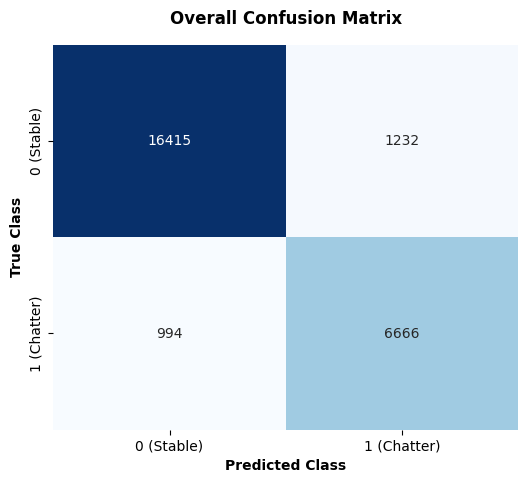

In [4]:


# 1. SEPARATE FILES BY GROUPS (Letters and Numbers)
unique_files = list(groups.unique())

# Extract the actual ID (part after '_') to safely check if it's a letter or number
# e.g., 'cutting_A'.split('_')[-1] -> 'A' -> isalpha() is True
letter_files = [str(f) for f in unique_files if str(f).split('_')[-1].isalpha()] 
number_files = [str(f) for f in unique_files if str(f).split('_')[-1].isdigit()]

print(f"Files with Letters (Chatter-Weighted): {letter_files}")
print(f"Files with Numbers (Stable-Weighted): {number_files}\n")

all_y_true, all_y_pred, all_y_proba, all_file_id = [], [], [], []
fold_accuracies, fold_names, fold_feature_importances = [], [], []
all_eval_results = {} 

random.seed(42)

# 2. TRUE LOOCV (Leave-One-Out Cross Validation) LOOP
for fold_idx, test_file_id in enumerate(unique_files):
    test_file_id_str = str(test_file_id)
    
    # Find remaining files (excluding the Test file)
    remaining_files = [str(f) for f in unique_files if str(f) != test_file_id_str]
    
    # 3. DYNAMIC AND BALANCED VALIDATION SET SELECTION
    # Randomly select 1 file with a letter and 1 with a number from the remaining files
    suitable_letters = [f for f in remaining_files if f in letter_files]
    suitable_numbers = [f for f in remaining_files if f in number_files]
    
    # Safety measure to avoid errors if no suitable letters/numbers remain in that fold
    if not suitable_letters or not suitable_numbers:
        print(f"Skipping fold {fold_idx + 1} for {test_file_id_str} (Not enough validation files)")
        continue 
        
    val_file_1 = random.choice(suitable_letters)
    val_file_2 = random.choice(suitable_numbers)
    val_files = [val_file_1, val_file_2]
    
    # 4. REMAINING FOR THE TRAIN SET
    train_files = [f for f in remaining_files if f not in val_files]
    
    print(f"Fold {fold_idx + 1:02d} | Test: {test_file_id_str:<10} | Val: {str(val_files):<25} | Train: {len(train_files)} files")

    # Create masks
    test_mask = (groups.astype(str) == test_file_id_str)
    val_mask = groups.astype(str).isin(val_files)
    train_mask = groups.astype(str).isin(train_files)
    
    # Split sets
    X_test, y_test = X[test_mask], y[test_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    X_train, y_train = X[train_mask], y[train_mask]
    
    eval_set = [(X_train, y_train), (X_val, y_val)]
    
    # 5. CLONE AND TRAIN THE MODEL (With your Overfitting-protected parameters)
    fold_model = clone(model)
    fold_model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
    
    all_eval_results[test_file_id_str] = fold_model.evals_result()
    
    # 6. TEST AND SAVE
    if len(X_test) > 0:
        y_pred_proba = fold_model.predict_proba(X_test)[:, 1] 
        y_pred = (y_pred_proba >= 0.50).astype(int)
        
        all_y_true.extend(y_test.values)
        all_y_pred.extend(y_pred)
        all_y_proba.extend(y_pred_proba) 
        all_file_id.extend([test_file_id_str] * len(y_test)) 
        
        acc = accuracy_score(y_test, y_pred)
        fold_accuracies.append(acc)
        fold_names.append(test_file_id_str)
        fold_feature_importances.append(fold_model.feature_importances_)

# ====================================================================
# RESULTS TABLE
# ====================================================================
df_results = pd.DataFrame({
    'File_ID': all_file_id,
    'True_Class': all_y_true,
    'Raw_Prediction': all_y_pred,
    'Probability': all_y_proba
})
print("\n✅ Predictions have been saved to the 'df_results' table for Cell 6!")

# ====================================================================
# PERFORMANCE METRICS
# ====================================================================
print("\n--- TEST SET PERFORMANCE RESULTS (Threshold: 0.5) ---")
print(f"Overall Accuracy Rate: {accuracy_score(all_y_true, all_y_pred):.4f}\n")

print("Classification Report:")
report_dict = classification_report(all_y_true, all_y_pred, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df.round(3))

# Confusion Matrix
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['0 (Stable)', '1 (Chatter)'], 
            yticklabels=['0 (Stable)', '1 (Chatter)'])
plt.title("Overall Confusion Matrix", pad=15, fontweight='bold')
plt.ylabel("True Class", fontweight='bold')
plt.xlabel("Predicted Class", fontweight='bold')
plt.show()

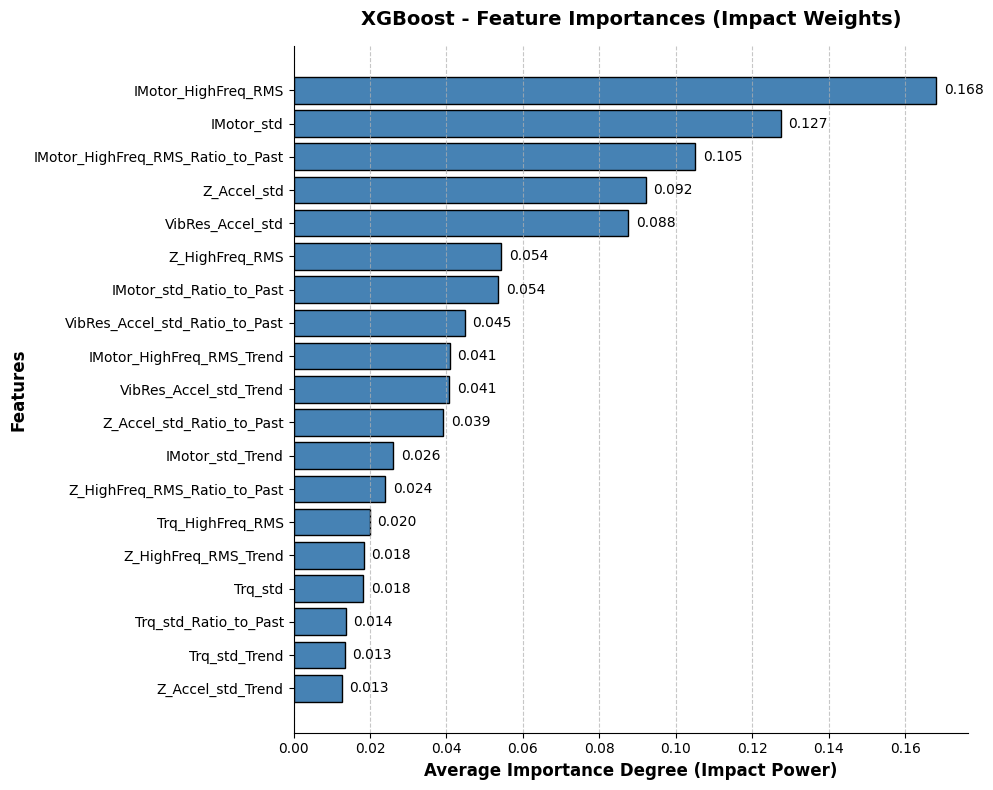

In [5]:

# 1. CALCULATE AVERAGE IMPORTANCE DEGREES
# fold_feature_importances list was filled in each fold in the previous code block (Cell 3 or 4)
avg_importance = np.mean(fold_feature_importances, axis=0)

# 2. MATCH WITH FEATURES AND SORT
try:
    feature_names = feature_columns
except NameError:
    feature_names = X.columns 

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': avg_importance
}).sort_values(by='Importance', ascending=True)

# 3. PLOT THE GRAPH
plt.figure(figsize=(10, 8))

# Create the bars 
bars = plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', edgecolor='black')

# Axis settings
plt.xlabel('Average Importance Degree (Impact Power)', fontweight='bold', fontsize=12)
plt.ylabel('Features', fontweight='bold', fontsize=12)
plt.title('XGBoost - Feature Importances (Impact Weights)', fontweight='bold', fontsize=14, pad=15)

# 4. PRINT VALUES AT THE ENDS OF THE BARS
for bar in bars:
    
    width = bar.get_width()
    plt.text(width + 0.002, 
             bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', 
             va='center', 
             ha='left', 
             fontsize=10,
             color='black')

# Grid and layout settings
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

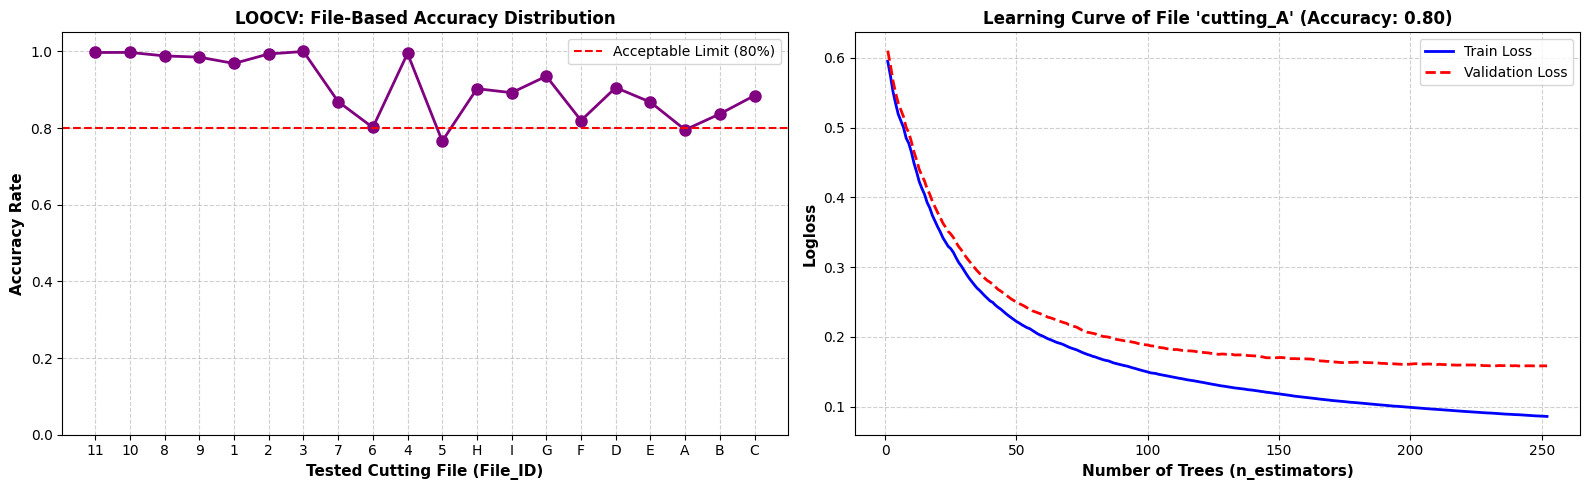

In [6]:
# ==========================================
target_file = 'cutting_A'  
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1st GRAPH: File-Based Performance Curve (General Table)
# Clean the names strictly for the X-axis (e.g., 'cutting_1' -> '1')
clean_fold_names = [str(name).replace('.csv', '').split('_')[-1] for name in fold_names]
axes[0].plot(clean_fold_names, fold_accuracies, marker='o', linestyle='-', color='purple', linewidth=2, markersize=8)
axes[0].axhline(y=0.80, color='r', linestyle='--', label='Acceptable Limit (80%)')
axes[0].set_title("LOOCV: File-Based Accuracy Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Tested Cutting File (File_ID)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Accuracy Rate", fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 2nd GRAPH: Learning Curve (Logloss) for the Manually Selected File

if target_file in all_eval_results:
    history = all_eval_results[target_file]
    train_loss = history['validation_0']['logloss']
    val_loss = history['validation_1']['logloss']
    epochs = range(1, len(train_loss) + 1)
    
    
    file_acc = fold_accuracies[fold_names.index(target_file)]
    
    axes[1].plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
    axes[1].plot(epochs, val_loss, 'r--', label='Validation Loss', linewidth=2)
    axes[1].set_title(f"Learning Curve of File '{target_file}' (Accuracy: {file_acc:.2f})", fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Number of Trees (n_estimators)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Logloss', fontsize=11, fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend()
else:
    
    axes[1].text(0.5, 0.5, f"File with ID '{target_file}' not found.\nPlease enter an existing File_ID.", 
                 ha='center', va='center', fontsize=13, color='red', fontweight='bold')
    axes[1].set_title("Invalid File Selection", fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [7]:
for f, h in all_eval_results.items():
    print(f"Dosya {f}: {len(h['validation_0']['logloss'])} iteration.")

Dosya cutting_11: 470 iteration.
Dosya cutting_10: 398 iteration.
Dosya cutting_8: 187 iteration.
Dosya cutting_9: 305 iteration.
Dosya cutting_1: 284 iteration.
Dosya cutting_2: 177 iteration.
Dosya cutting_3: 344 iteration.
Dosya cutting_7: 192 iteration.
Dosya cutting_6: 235 iteration.
Dosya cutting_4: 371 iteration.
Dosya cutting_5: 99 iteration.
Dosya cutting_H: 174 iteration.
Dosya cutting_I: 253 iteration.
Dosya cutting_G: 355 iteration.
Dosya cutting_F: 443 iteration.
Dosya cutting_D: 147 iteration.
Dosya cutting_E: 451 iteration.
Dosya cutting_A: 252 iteration.
Dosya cutting_B: 295 iteration.
Dosya cutting_C: 294 iteration.


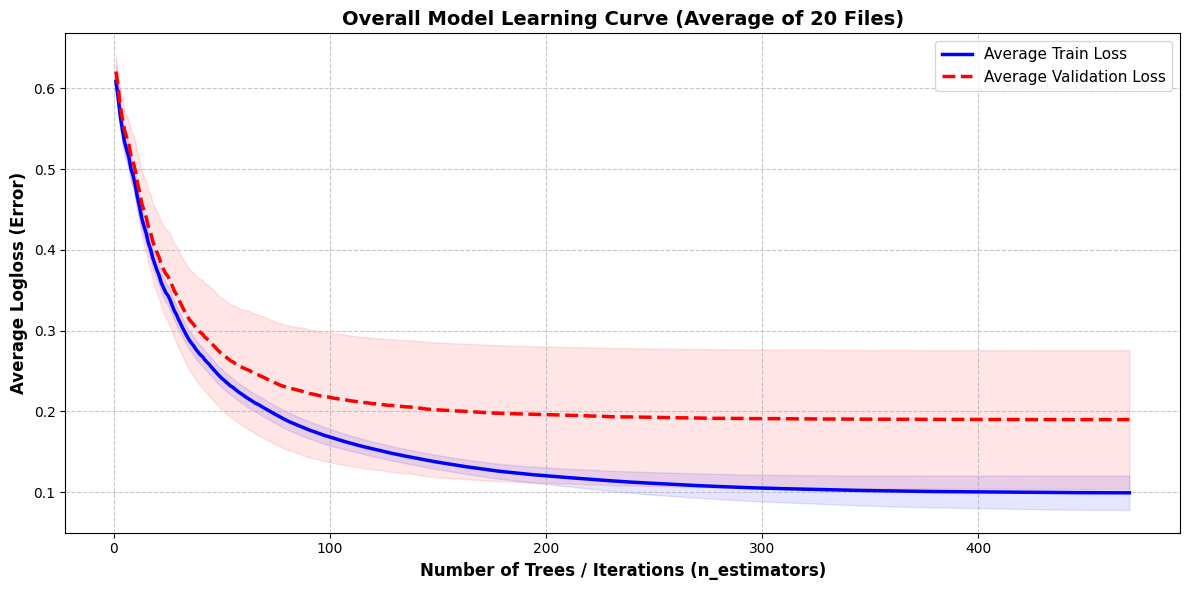

In [8]:


# =====================================================================
# EXTRACTING THE AVERAGE LEARNING CURVE OF ALL FILES (FOLDS)
# =====================================================================

# 1.find the maximum number of epochs (trees)
max_epochs = 0
for fold_name, history in all_eval_results.items():
    epochs_len = len(history['validation_0']['logloss'])
    if epochs_len > max_epochs:
        max_epochs = epochs_len

# 2.create empty matrices to hold the loss values of all folds
n_folds = len(all_eval_results)
train_loss_matrix = np.zeros((n_folds, max_epochs))
val_loss_matrix = np.zeros((n_folds, max_epochs))

# 3.fill the matrices (Extending the early stopped ones with their last value)
for idx, (fold_name, history) in enumerate(all_eval_results.items()):
    t_loss = history['validation_0']['logloss']
    v_loss = history['validation_1']['logloss']
    
    # Write the existing parts to the matrix
    train_loss_matrix[idx, :len(t_loss)] = t_loss
    val_loss_matrix[idx, :len(v_loss)] = v_loss
    
    # If there is early stopping, copy the last value in the list up to the maximum epoch
    if len(t_loss) < max_epochs:
        train_loss_matrix[idx, len(t_loss):] = t_loss[-1]
        val_loss_matrix[idx, len(v_loss):] = v_loss[-1]

# 4.calculate the Mean and Standard Deviations (Std)
mean_train_loss = np.mean(train_loss_matrix, axis=0)
std_train_loss = np.std(train_loss_matrix, axis=0)

mean_val_loss = np.mean(val_loss_matrix, axis=0)
std_val_loss = np.std(val_loss_matrix, axis=0)

# 5.plot the General Learning Curve
plt.figure(figsize=(12, 6))
epochs = np.arange(1, max_epochs + 1)

# Train Loss Curve and Variance Band
plt.plot(epochs, mean_train_loss, 'b-', label='Average Train Loss', linewidth=2.5)
plt.fill_between(epochs, mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, color='b', alpha=0.1)

# Validation Loss Curve and Variance Band
plt.plot(epochs, mean_val_loss, 'r--', label='Average Validation Loss', linewidth=2.5)
plt.fill_between(epochs, mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, color='r', alpha=0.1)

plt.title(f"Overall Model Learning Curve (Average of 20 Files)", fontsize=14, fontweight='bold')
plt.xlabel('Number of Trees / Iterations (n_estimators)', fontsize=12, fontweight='bold')
plt.ylabel('Average Logloss (Error)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [9]:


# --- EXPORT RESULTS ---
# Define the output directory (Creating a new folder for results)
results_dir = "../02_Processed_Data/07_Model_Results"
os.makedirs(results_dir, exist_ok=True)

# Define the file path
output_csv_path = os.path.join(results_dir, "LOOCV_Predictions_Results.csv")

# Export the df_results dataframe to CSV (without the index column)
df_results.to_csv(output_csv_path, index=False)

print(f"✅ All predictions have been successfully exported to:\n📂 {output_csv_path}")

✅ All predictions have been successfully exported to:
📂 ../02_Processed_Data/07_Model_Results/LOOCV_Predictions_Results.csv
